1. Importaciones y configuración inicial

In [1]:
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt
#Para modelo regresión lineal múltiple:
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
#Para Random Forest:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
#Para buscar mejores parámetros de RF:
from sklearn.model_selection import GridSearchCV
#Para crear gráficos de dependencia parcial:
from sklearn.inspection import PartialDependenceDisplay

ruta_carpeta_csv = r"C:\Users\misab\Documents\IT Academy\Especialitzacio\sprint 13\notebooks\data\processed"

2. Importar csv

In [2]:
df_correlaciones = pd.read_csv(os.path.join(ruta_carpeta_csv, "df_correlaciones.csv"))

df_correlaciones

,country_code,country_name,year,gini,home_ownership_rate,unemployment_rate,early_leavers,healthy_life_years,gdp_capita_real,inflation_rate
0,AT,Austria,2014,27.6,57.2,6.0,7.0,57.7,43070.0,1.5
1,AT,Austria,2015,27.2,55.7,6.1,7.3,58.0,43200.0,0.8
2,AT,Austria,2016,27.2,55.0,6.5,6.9,57.0,43550.0,1.0
3,AT,Austria,2017,27.9,55.0,5.9,7.4,57.1,44260.0,2.2
4,AT,Austria,2018,26.8,55.4,5.2,7.3,56.9,45140.0,2.1
...,...,...,...,...,...,...,...,...,...,...
215,SK,Slovakia,2020,20.9,92.3,6.7,7.6,56.7,17270.0,2.0
216,SK,Slovakia,2021,21.8,92.9,6.8,7.8,56.8,18320.0,2.8
217,SK,Slovakia,2022,21.2,93.0,6.1,7.4,57.3,18360.0,12.1
218,SK,Slovakia,2023,21.6,93.6,5.8,6.4,57.5,18750.0,11.0


3. Exploración inicial

In [3]:
display(df_correlaciones.info())
display(round(df_correlaciones.describe(), 2))
print("\nValores nulos por dimensión:")
display(df_correlaciones.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_code         220 non-null    str    
 1   country_name         220 non-null    str    
 2   year                 220 non-null    int64  
 3   gini                 220 non-null    float64
 4   home_ownership_rate  220 non-null    float64
 5   unemployment_rate    220 non-null    float64
 6   early_leavers        220 non-null    float64
 7   healthy_life_years   220 non-null    float64
 8   gdp_capita_real      220 non-null    float64
 9   inflation_rate       220 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 17.3 KB


None

,year,gini,home_ownership_rate,unemployment_rate,early_leavers,healthy_life_years,gdp_capita_real,inflation_rate
count,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00
mean,2019.00,29.68,73.98,8.10,8.50,61.73,34454.27,2.45
std,3.17,3.69,10.36,4.26,3.67,4.83,21741.47,3.33
min,2014.00,20.90,46.50,2.90,2.00,51.40,11370.00,-1.50
25%,2016.00,26.88,69.50,5.57,6.20,57.78,19092.50,0.40
50%,2019.00,29.70,73.45,6.85,8.10,61.30,27835.00,1.40
75%,2022.00,32.32,80.98,9.33,10.12,65.62,43132.50,2.90
max,2024.00,37.90,93.60,26.60,21.90,73.60,107570.00,19.40



Valores nulos por dimensión:


country_code           0
country_name           0
year                   0
gini                   0
home_ownership_rate    0
unemployment_rate      0
early_leavers          0
healthy_life_years     0
gdp_capita_real        0
inflation_rate         0
dtype: int64

In [4]:
#Valorar distribuciones
nombres_columnas = list(df_correlaciones.columns)
variables = ['gini','home_ownership_rate','unemployment_rate','early_leavers','healthy_life_years','gdp_capita_real','inflation_rate']

for variable in variables:
    concentracion = round(df_correlaciones[variable].kurtosis(),2)
    asimetria = round(df_correlaciones[variable].skew(),2)
    print(f"La dimensión {variable} tiene una concentración de {concentracion} y asimetria de {asimetria}")

La dimensión gini tiene una concentración de -0.53 y asimetria de -0.16
La dimensión home_ownership_rate tiene una concentración de 0.23 y asimetria de -0.35
La dimensión unemployment_rate tiene una concentración de 4.3 y asimetria de 1.91
La dimensión early_leavers tiene una concentración de 0.86 y asimetria de 0.79
La dimensión healthy_life_years tiene una concentración de -0.61 y asimetria de 0.22
La dimensión gdp_capita_real tiene una concentración de 3.33 y asimetria de 1.85
La dimensión inflation_rate tiene una concentración de 6.86 y asimetria de 2.32


4. Correlaciones simples con Índice de Gini

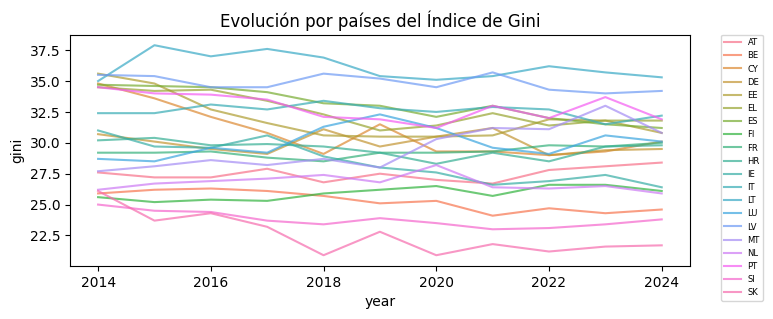

In [5]:
#Evolución por países del Índice de Gini:
plt.figure(figsize=(8,3))
sns.lineplot(data=df_correlaciones,x="year",y="gini",hue="country_code",alpha=0.7)
plt.title("Evolución por países del Índice de Gini")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, borderaxespad=0.)
plt.show()

In [6]:
corr_gini = df_correlaciones[variables].corr()

corr_gini

,gini,home_ownership_rate,unemployment_rate,early_leavers,healthy_life_years,gdp_capita_real,inflation_rate
gini,1.000000,0.135515,0.388491,0.265281,-0.002904,-0.232697,-0.045196
home_ownership_rate,0.135515,1.000000,0.194432,-0.153712,-0.283152,-0.471236,0.083743
unemployment_rate,0.388491,0.194432,1.000000,0.191541,0.062952,-0.337690,-0.323776
early_leavers,0.265281,-0.153712,0.191541,1.000000,0.257383,-0.085445,-0.129629
healthy_life_years,-0.002904,-0.283152,0.062952,0.257383,1.000000,0.212076,-0.078401
gdp_capita_real,-0.232697,-0.471236,-0.337690,-0.085445,0.212076,1.000000,-0.005171
inflation_rate,-0.045196,0.083743,-0.323776,-0.129629,-0.078401,-0.005171,1.000000


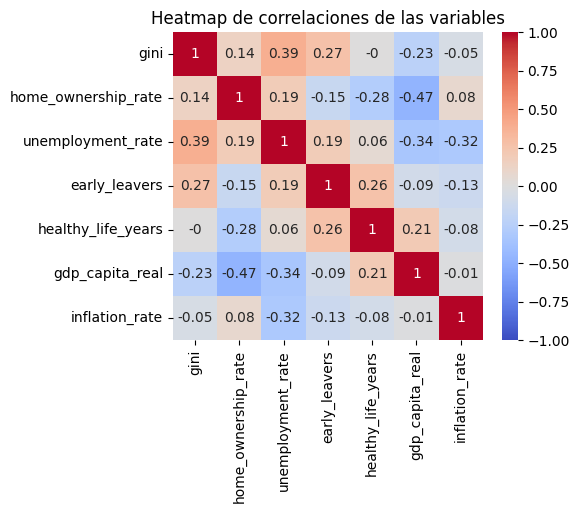

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(round(corr_gini,2), annot=True, cmap="coolwarm", center=0, vmax=1, vmin=-1)
plt.title("Heatmap de correlaciones de las variables")
plt.show()

<Figure size 800x600 with 0 Axes>

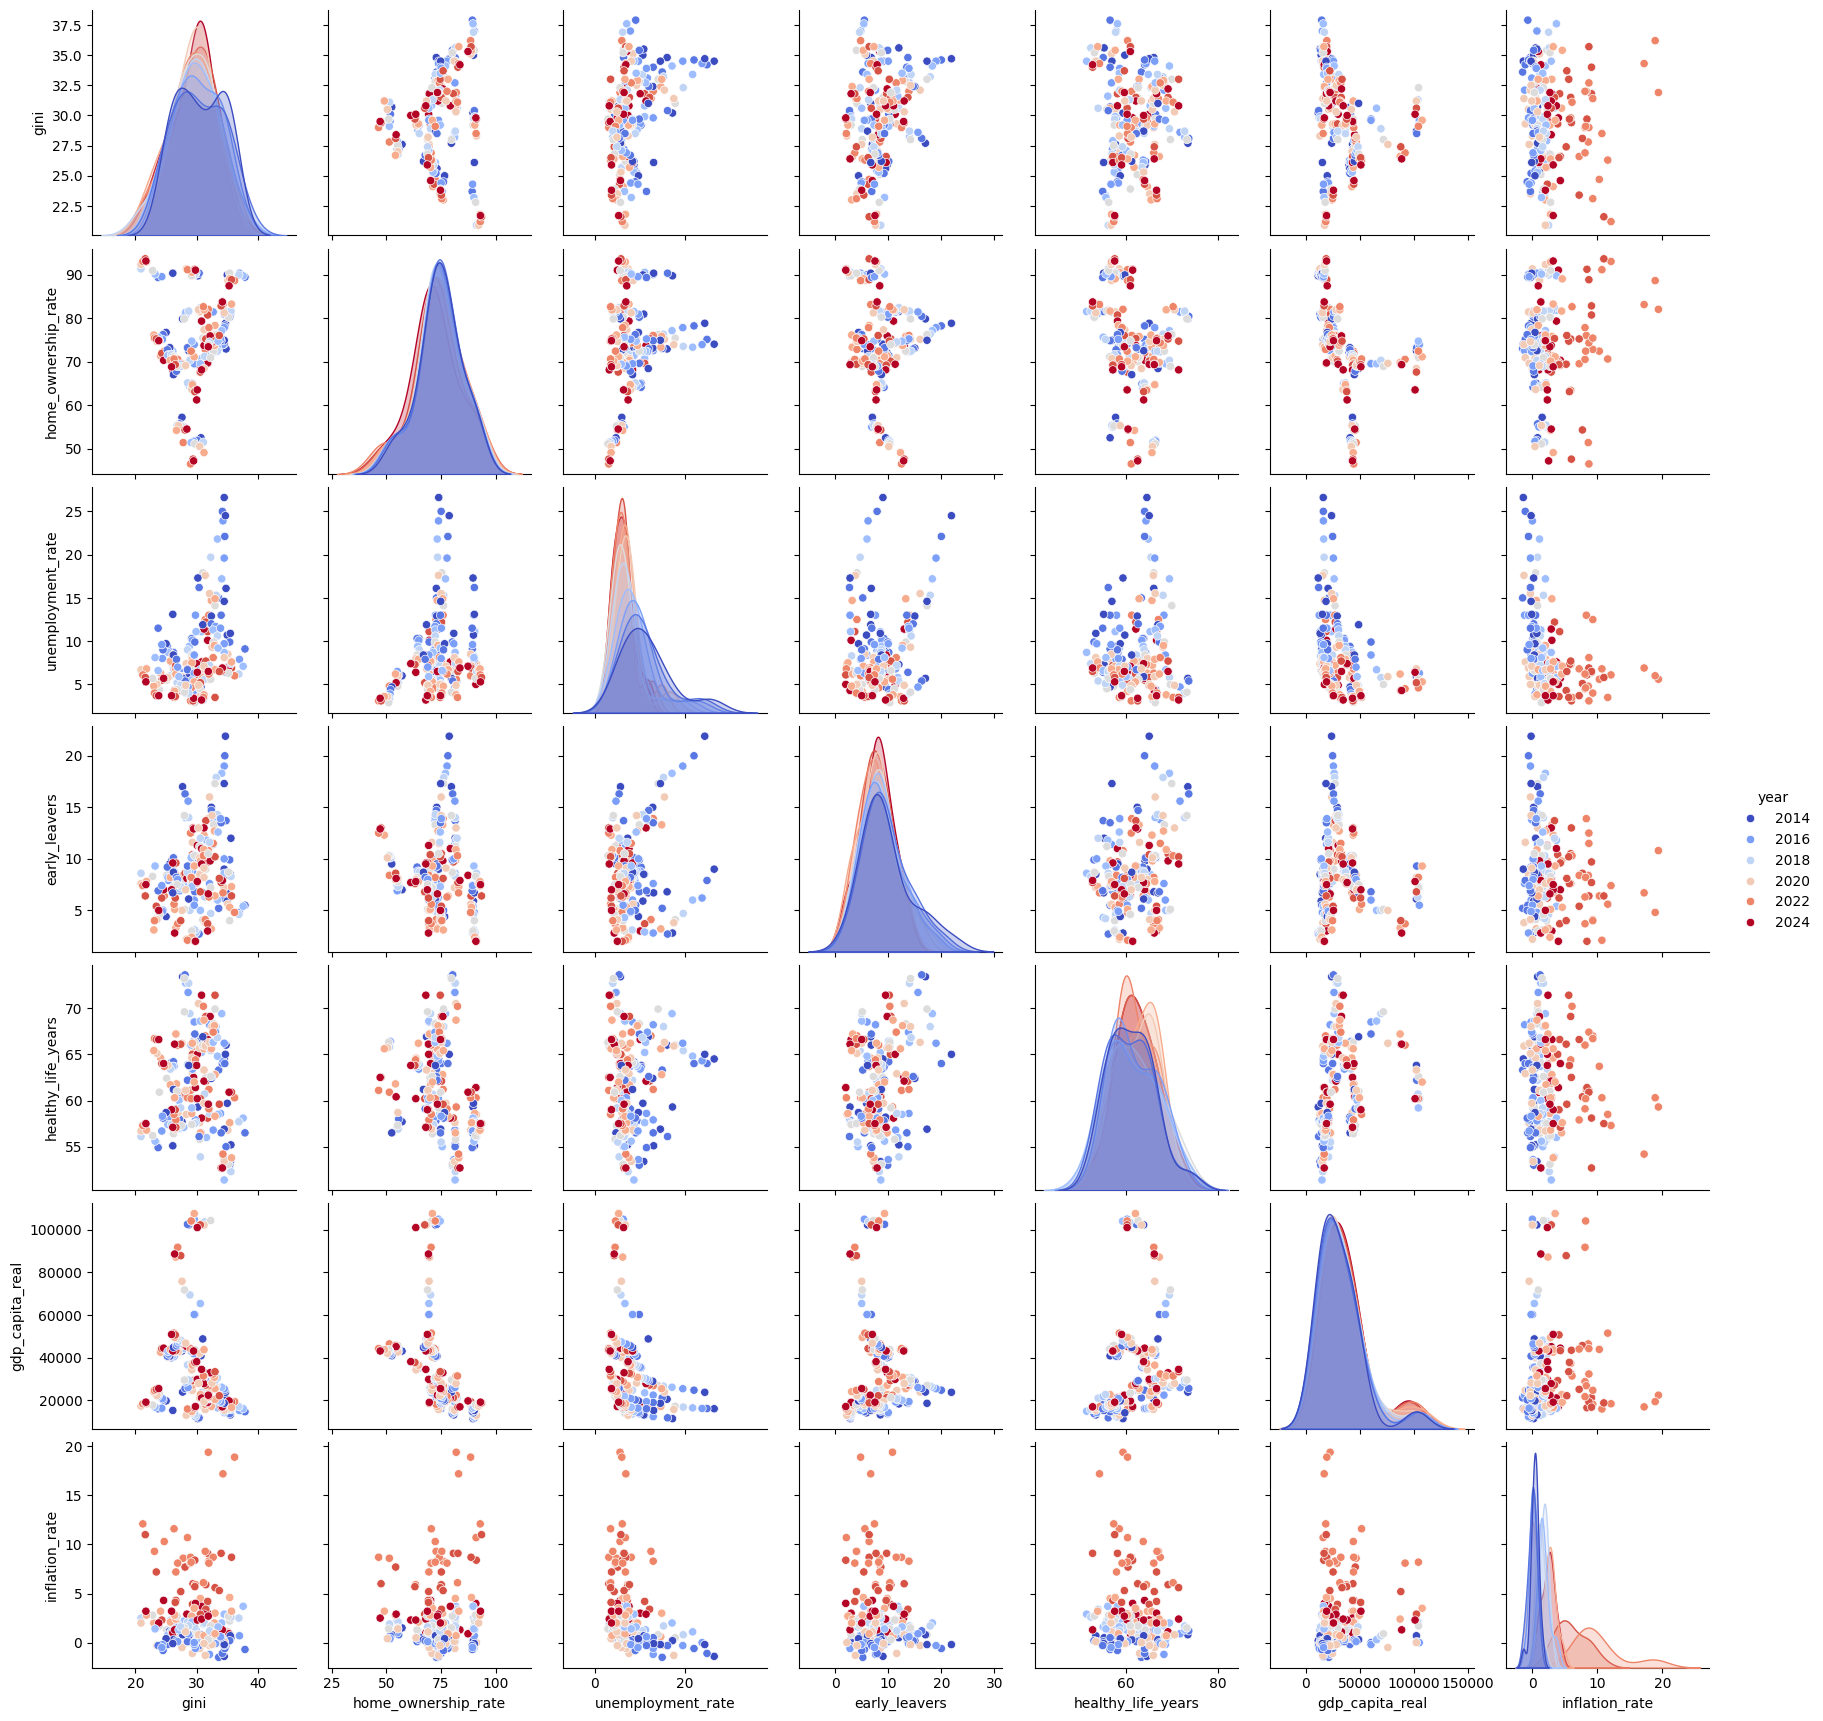

In [8]:
plt.figure(figsize=(8,6))
sns.pairplot(df_correlaciones, hue='year', vars=variables, palette='coolwarm')
plt.show()

5. Modelo de regresión lineal múltiple

In [9]:
#Crear un df para el modelo:
df_modelo = df_correlaciones[variables].copy()
df_modelo.head()

#Crear variables transformadas para corregir asimetría en base a resultados anteriores:
df_modelo["log_unemployment"] = np.log(df_modelo["unemployment_rate"])
df_modelo["log_gdp"] = np.log(df_modelo["gdp_capita_real"])
df_modelo["sqrt_early_leavers"] = np.sqrt(df_modelo["early_leavers"])
df_modelo.head()

#Definir variable dependiente (y) e independientes (x):
y = df_modelo["gini"]

x = df_modelo[[
    "home_ownership_rate",
    "log_unemployment",
    "sqrt_early_leavers",
    "healthy_life_years",
    "log_gdp",
    "inflation_rate"]]

#Crear y entrenar modelo:
modelo = LinearRegression()
modelo.fit(x, y)

pendientes = modelo.coef_
interseccion = modelo.intercept_

print("Pendientes (coeficientes) de cada variable en el orden de x.columns:")
for var, coef in zip(x.columns, pendientes):
    print(f"  - {var}: {round(coef, 4)}")
print(f"\nIntersección (término constante): {round(interseccion, 4)}")

#Coeficiente de calidad:
#“Qué porcentaje de la variabilidad de Gini explican TODAS las variables juntas”.
coef_R2 = modelo.score(x, y)
print(f"El coeficiente R² es de {round(coef_R2, 2)}, el modelo explica el {round(coef_R2*100, 2)}% de la variabilidad del Índice de Gini.")

Pendientes (coeficientes) de cada variable en el orden de x.columns:
  - home_ownership_rate: -0.0216
  - log_unemployment: 2.4772
  - sqrt_early_leavers: 1.3107
  - healthy_life_years: 0.0215
  - log_gdp: -1.7483
  - inflation_rate: 0.1015

Intersección (término constante): 39.0482
El coeficiente R² es de 0.23, el modelo explica el 23.48% de la variabilidad del Índice de Gini.


In [10]:
#Generar los p-value para valorar variables significativas para modelo

#Añadir constante:
x = sm.add_constant(x)

#Ajustar modelo:
modelo_sm = sm.OLS(y, x).fit()

#Mostrar resultados
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     10.89
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.43e-10
Time:                        10:24:19   Log-Likelihood:                -569.68
No. Observations:                 220   AIC:                             1153.
Df Residuals:                     213   BIC:                             1177.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  39.0482    

In [11]:
#Esacalar variables para poder comparar
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)

x_scaled_sm = sm.add_constant(x_scaled)
modelo_sm = sm.OLS(y, x_scaled_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     10.89
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.43e-10
Time:                        10:24:19   Log-Likelihood:                -569.68
No. Observations:                 220   AIC:                             1153.
Df Residuals:                     213   BIC:                             1177.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  29.6777    

6. Random Forest Regressor

In [12]:
#OPCIÓN 1: Usando variables transformadas de modelo lineal para comparar

y1 = df_modelo["gini"]
x1 = df_modelo[[
    "home_ownership_rate",
    "log_unemployment",
    "sqrt_early_leavers",
    "healthy_life_years",
    "log_gdp",
    "inflation_rate"]]
#Separar en train y test:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
#Crear el modelo Random Forest:
rf1 = RandomForestRegressor(
    n_estimators=500,   # número de árboles
    max_depth=None,     # profundidad libre (los árboles crecen hasta que haga falta)
    random_state=42)
#Entrenar el modelo:
rf1.fit(x1_train, y1_train)
#Hacer predicciones en el conjunto de test:
y_pred_rf1 = rf1.predict(x1_test)
#Evaluar el modelo: R² y RMSE:
r2_rf1 = r2_score(y1_test, y_pred_rf1)
mse_rf1 = mean_squared_error(y1_test, y_pred_rf1)
rmse_rf1 = np.sqrt(mse_rf1)
print(f"R² Random Forest (test): {round(r2_rf1, 4)}")
print(f"RMSE Random Forest (test): {round(rmse_rf1, 4)}")
#Ver la importancia de las variables:
importancias1 = pd.Series(rf1.feature_importances_, index=x1.columns)
importancias1.sort_values(ascending=False, inplace=True)
print(importancias1)

R² Random Forest (test): 0.5842
RMSE Random Forest (test): 2.3733
log_gdp                0.279294
home_ownership_rate    0.250718
sqrt_early_leavers     0.179415
log_unemployment       0.175933
healthy_life_years     0.087678
inflation_rate         0.026963
dtype: float64


In [13]:
#OPCIÓN 2: Random forest con variables originales (Con el que profundizaré)

y2 = df_modelo["gini"]
x2 = df_modelo[[
    'home_ownership_rate',
    'unemployment_rate',
    'early_leavers',
    'healthy_life_years',
    'gdp_capita_real',
    'inflation_rate']]

#Separar en train y test:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)
#Crear el modelo Random Forest:
rf2 = RandomForestRegressor(
    n_estimators=500,   # número de árboles
    max_depth=None,     # profundidad libre (los árboles crecen hasta que haga falta)
    random_state=42)
#Entrenar el modelo:
rf2.fit(x2_train, y2_train)
#Hacer predicciones en el conjunto de test:
y_pred_rf2 = rf2.predict(x2_test)
#Evaluar el modelo: R² y RMSE:
r2_rf2 = r2_score(y2_test, y_pred_rf2)
mse_rf2 = mean_squared_error(y2_test, y_pred_rf2)
rmse_rf2 = np.sqrt(mse_rf2)
print(f"R² Random Forest (test): {round(r2_rf2, 4)}")
print(f"RMSE Random Forest (test): {round(rmse_rf2, 4)}")
#Ver la importancia de las variables:
importancias2 = pd.Series(rf2.feature_importances_, index=x2.columns)
importancias2.sort_values(ascending=False, inplace=True)
print(importancias2)


R² Random Forest (test): 0.5843
RMSE Random Forest (test): 2.3729
gdp_capita_real        0.279294
home_ownership_rate    0.250718
early_leavers          0.179415
unemployment_rate      0.175933
healthy_life_years     0.087678
inflation_rate         0.026963
dtype: float64


In [14]:
#Intentar mejorar Random Forest opción 2 (variables originales)

#Cambiar n_estimators (número de árboles):
for n in [100, 200, 500, 1000]:
    rf2 = RandomForestRegressor(
        n_estimators=n,
        max_depth=None,
        random_state=42)
    rf2.fit(x2_train, y2_train)
    y_pred_rf2 = rf2.predict(x2_test)
    r2 = r2_score(y2_test, y_pred_rf2)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred_rf2))
    print(f"n_estimators={n} -> R²={r2:.4f}, RMSE={rmse:.4f}")

n_estimators=100 -> R²=0.5894, RMSE=2.3584
n_estimators=200 -> R²=0.5813, RMSE=2.3815
n_estimators=500 -> R²=0.5843, RMSE=2.3729
n_estimators=1000 -> R²=0.5839, RMSE=2.3742


In [15]:
#Cambiar max_depth (número de variables consideradas en cada división):
for depth in [3, 5, 7, 10, None]:
    rf2 = RandomForestRegressor(
        n_estimators=500, #no es significativo resultado anterior, 500 para más estabilidad del modelo
        max_depth=depth,
        random_state=42)
    rf2.fit(x2_train, y2_train)
    y_pred_rf2 = rf2.predict(x2_test)
    r2 = r2_score(y2_test, y_pred_rf2)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred_rf2))
    print(f"max_depth={depth} -> R²={r2:.4f}, RMSE={rmse:.4f}")

max_depth=3 -> R²=0.3389, RMSE=2.9925
max_depth=5 -> R²=0.4838, RMSE=2.6444
max_depth=7 -> R²=0.5433, RMSE=2.4874
max_depth=10 -> R²=0.5829, RMSE=2.3771
max_depth=None -> R²=0.5843, RMSE=2.3729


In [16]:
#Probar min_samples_split y min_samples_leaf:
for split in [2, 5, 10]:
    for leaf in [1, 2, 4]:
        rf2 = RandomForestRegressor(
            n_estimators=500,
            max_depth=10,   #elegir 10 para tener un modelo más estable y menos propenso a ruido
            min_samples_split=split,
            min_samples_leaf=leaf,
            random_state=42)
        rf2.fit(x2_train, y2_train)
        y_pred_rf2 = rf2.predict(x2_test)
        r2 = r2_score(y2_test, y_pred_rf2)
        rmse = np.sqrt(mean_squared_error(y2_test, y_pred_rf2))
        print(f"split={split}, leaf={leaf} -> R²={r2:.4f}, RMSE={rmse:.4f}")

split=2, leaf=1 -> R²=0.5829, RMSE=2.3771
split=2, leaf=2 -> R²=0.5339, RMSE=2.5127
split=2, leaf=4 -> R²=0.4691, RMSE=2.6817
split=5, leaf=1 -> R²=0.5792, RMSE=2.3875
split=5, leaf=2 -> R²=0.5376, RMSE=2.5027
split=5, leaf=4 -> R²=0.4691, RMSE=2.6817
split=10, leaf=1 -> R²=0.5240, RMSE=2.5393
split=10, leaf=2 -> R²=0.5020, RMSE=2.5972
split=10, leaf=4 -> R²=0.4650, RMSE=2.6920


In [17]:
#Probar max_features:
for mf in ['sqrt', 0.5, 1.0]:
    rf2 = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_split=2, #mejor resultado con divisiones flexibles (split=2)
        min_samples_leaf=1, #mejor resultado con hojas pequeñas (leaf=1)
        max_features=mf,
        random_state=42)
    rf2.fit(x2_train, y2_train)
    y_pred_rf2 = rf2.predict(x2_test)
    r2 = r2_score(y2_test, y_pred_rf2)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred_rf2))
    print(f"max_features={mf} -> R²={r2:.4f}, RMSE={rmse:.4f}")

max_features=sqrt -> R²=0.5139, RMSE=2.5661
max_features=0.5 -> R²=0.5473, RMSE=2.4764
max_features=1.0 -> R²=0.5829, RMSE=2.3771


In [27]:
#Modelo final Random forest:
y = df_modelo["gini"]
x = df_modelo[[
    'home_ownership_rate',
    'unemployment_rate',
    'early_leavers',
    'healthy_life_years',
    'gdp_capita_real',
    'inflation_rate']]

#Separar en train y test:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#GridSearchCV para automatizar búsqueda de mejores parámetros:
param_grid = {
    'n_estimators': [800, 1200],
    'max_depth': [12, 15, None],
    'min_samples_split': [2,4],
    'min_samples_leaf': [1,2],
    'max_features': [0.8, 1.0]}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1)

grid.fit(x_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor R² CV:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print("R² test:", r2_score(y_test, y_pred_rf))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

importancias = pd.Series(best_rf.feature_importances_, index=x.columns)
importancias.sort_values(ascending=False, inplace=True)
print(importancias)

Mejores parámetros: {'max_depth': 12, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}
Mejor R² CV: 0.5893478397323104
R² test: 0.5908551660846592
RMSE test: 2.354169051735116
gdp_capita_real        0.276246
home_ownership_rate    0.249529
early_leavers          0.182717
unemployment_rate      0.173867
healthy_life_years     0.088916
inflation_rate         0.028725
dtype: float64


In [28]:
#Modelo final Random forest:
y = df_modelo["gini"]
x = df_modelo[[
    'home_ownership_rate',
    'unemployment_rate',
    'early_leavers',
    'healthy_life_years',
    'gdp_capita_real',
    'inflation_rate']]

#Separar en train y test:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#Crear el modelo Random Forest:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42)
#Entrenar el modelo:
rf.fit(x_train, y_train)
#Hacer predicciones en el conjunto de test:
y_pred_rf = rf.predict(x_test)
#Evaluar el modelo: R² y RMSE:
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"R² Random Forest (test): {round(r2_rf, 4)}")
print(f"RMSE Random Forest (test): {round(rmse_rf, 4)}")
#Ver la importancia de las variables:
importancias = pd.Series(rf.feature_importances_, index=x.columns)
importancias.sort_values(ascending=False, inplace=True)
print(importancias)

R² Random Forest (test): 0.5909
RMSE Random Forest (test): 2.3542
gdp_capita_real        0.276246
home_ownership_rate    0.249529
early_leavers          0.182717
unemployment_rate      0.173867
healthy_life_years     0.088916
inflation_rate         0.028725
dtype: float64


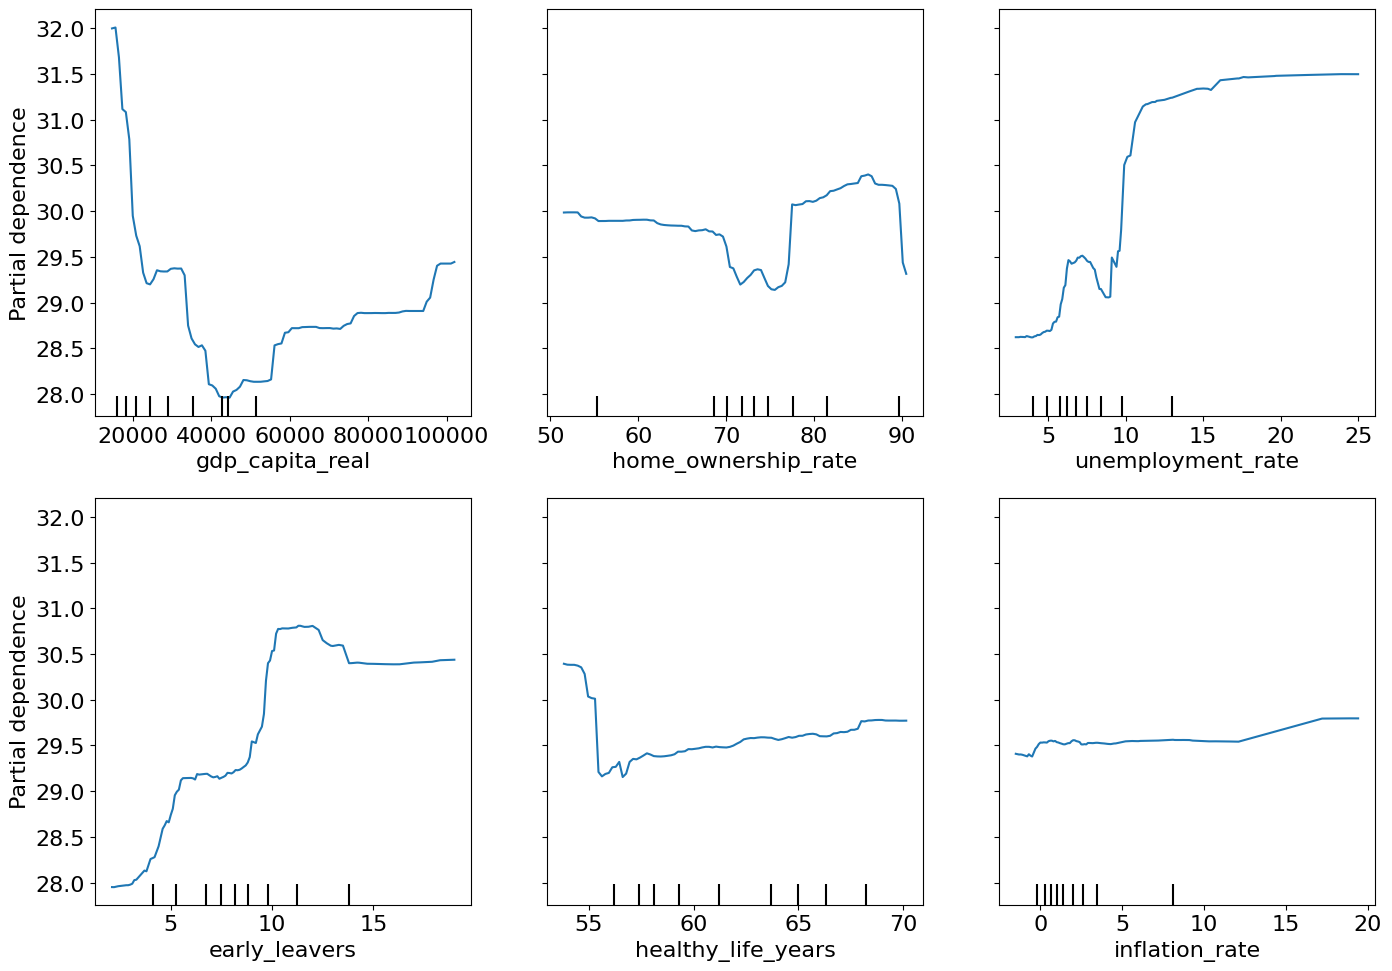

In [29]:
#Gráficos de dependencia parcial:
features = [
    'gdp_capita_real',
    'home_ownership_rate',
    'unemployment_rate',
    'early_leavers',
    'healthy_life_years',
    'inflation_rate']

fig, ax = plt.subplots(figsize=(14, 10))
plt.rcParams.update({"font.size": 16})
PartialDependenceDisplay.from_estimator(
    rf,
    x_train,
    features,
    ax=ax)
plt.tight_layout()
plt.show()

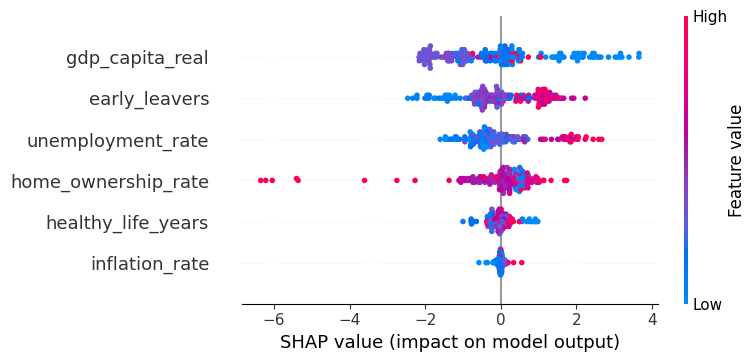

In [30]:
#EXTRA:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_train)

shap.summary_plot(shap_values, x_train)

Este gráfico se llama SHAP Summary Plot.
Cada punto es un país.
Cada fila es una variable.
El eje horizontal muestra cuánto empuja esa variable la predicción hacia arriba o hacia abajo.
- Valores SHAP positivos → aumentan el Gini (más desigualdad)
- Valores SHAP negativos → reducen el Gini (menos desigualdad)
El color indica si el valor de la variable es:
- Alto → rosa
- Bajo → azul